In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("all libraries loaded")

all libraries loaded


In [2]:
df = pd.read_csv("/content/cybersecurity_intrusion_data.csv")

In [3]:
print(df.head())

  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected  
0         Edge                    0                1  
1      Firefox                    0 

In [4]:
print(df.columns.tolist())

['session_id', 'network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access', 'attack_detected']


In [5]:
print(df.columns)

Index(['session_id', 'network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='object')


In [6]:
print(df.isnull().sum())

session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64


In [7]:
df['encryption_used'].fillna('Unknown',inplace=True)

/tmp/ipykernel_2423/3951086812.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['encryption_used'].fillna('Unknown',inplace=True)


In [9]:
print("Attack v/s Normal:")
print(df['attack_detected'].value_counts())
print("\npercentage:")
print(df['attack_detected'].value_counts(normalize=True)*100)

Attack v/s Normal:
attack_detected
0    5273
1    4264
Name: count, dtype: int64

percentage:
attack_detected
0    55.289923
1    44.710077
Name: proportion, dtype: float64


In [10]:
print(df.dtypes)

session_id              object
network_packet_size      int64
protocol_type           object
login_attempts           int64
session_duration       float64
encryption_used         object
ip_reputation_score    float64
failed_logins            int64
browser_type            object
unusual_time_access      int64
attack_detected          int64
dtype: object


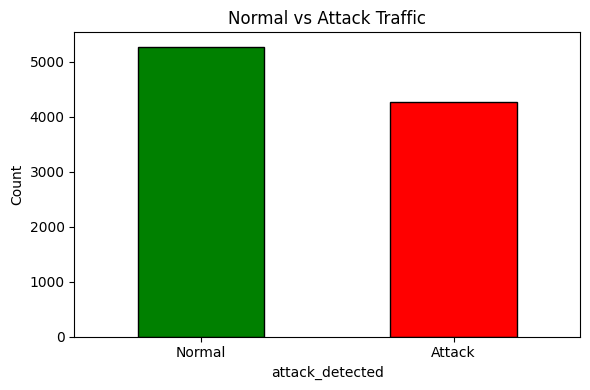

In [12]:
df['attack_detected'].value_counts().plot(kind='bar',figsize=(6,4),color=['green','red'],edgecolor=['black'],title='Normal vs Attack Traffic')
plt.xticks([0,1],['Normal','Attack'],rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [15]:
numerical_cols = ['network_packet_size','login_attempts','failed_logins','unusual_time_access','attack_detected']
print("average values - normal v/s attack")
print(df.groupby('attack_detected')[numerical_cols].mean().round(2).T)

average values - normal v/s attack
attack_detected           0       1
network_packet_size  501.64  498.93
login_attempts         3.54    4.64
failed_logins          1.18    1.94
unusual_time_access    0.15    0.15
attack_detected        0.00    1.00


In [17]:
print(df.groupby('attack_detected')[['ip_reputation_score','session_duration']].mean().round(2))

                 ip_reputation_score  session_duration
attack_detected                                       
0                               0.30            763.32
1                               0.37            829.13


# **Protocol Type:** Which protocol has the highest attack rate — TCP, UDP, or ICMP?

In [35]:
protocolP_type = df.groupby('protocol_type')['attack_detected'].mean()

In [36]:
print(protocolP_type)

protocol_type
ICMP    0.412229
TCP     0.447313
UDP     0.453865
Name: attack_detected, dtype: float64


# **Browser Type Analysis**

In [37]:
print(df['browser_type'].value_counts())

browser_type
Chrome     5137
Firefox    1944
Edge       1469
Unknown     502
Safari      485
Name: count, dtype: int64


In [38]:
df.groupby('browser_type')['attack_detected'].mean()

,attack_detected
browser_type,
Chrome,0.428655
Edge,0.437713
Firefox,0.436728
Safari,0.418557
Unknown,0.731076


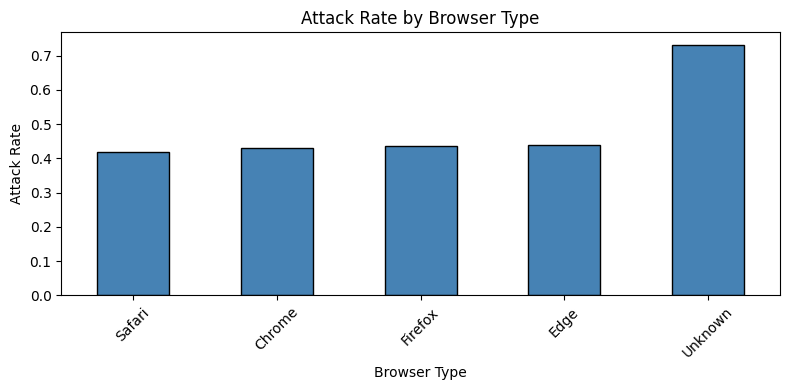

In [39]:
df.groupby('browser_type')['attack_detected'].mean().sort_values().plot(kind='bar',color='steelblue',edgecolor='black',figsize=(8,4))

plt.title('Attack Rate by Browser Type')
plt.xlabel('Browser Type')
plt.ylabel('Attack Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Encryption Analysis**

In [40]:
print(df['encryption_used'].value_counts())

encryption_used
AES        4706
DES        2865
Unknown    1966
Name: count, dtype: int64


In [41]:
encryption_types = df.groupby('encryption_used')['attack_detected'].mean()

In [42]:
print(encryption_types)

encryption_used
AES        0.436677
DES        0.453403
Unknown    0.462869
Name: attack_detected, dtype: float64


# **Failed Logins Distribution**

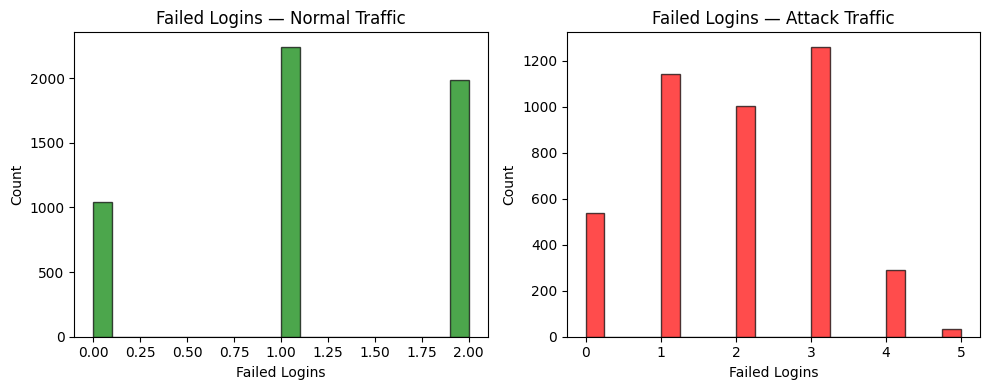

In [43]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df[df['attack_detected']==0]['failed_logins'].plot(kind='hist', bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title('Failed Logins — Normal Traffic')
plt.xlabel('Failed Logins')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df[df['attack_detected']==1]['failed_logins'].plot(kind='hist', bins=20, color='red', edgecolor='black', alpha=0.7)
plt.title('Failed Logins — Attack Traffic')
plt.xlabel('Failed Logins')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# **Correlation Heatmap**

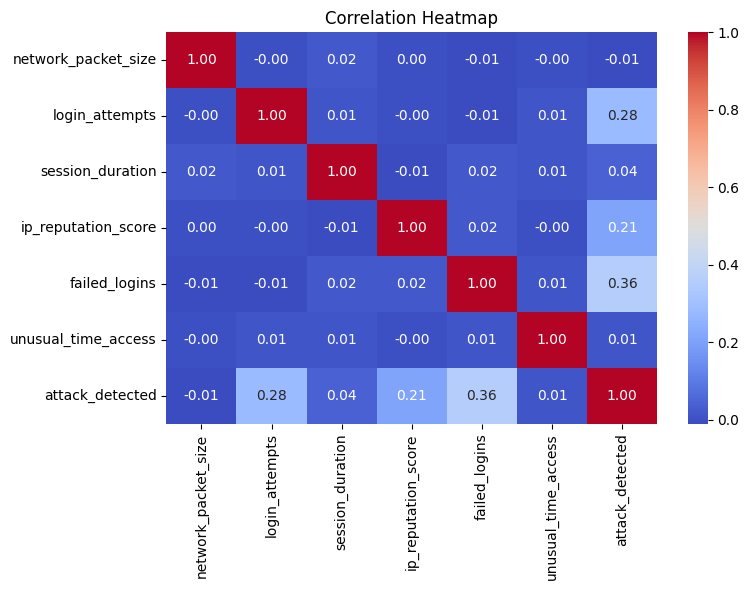

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr().round(2),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# **Anomaly Detection Model**

In [45]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest

In [46]:
df_model = df.copy()
for col in ['protocol_type', 'encryption_used', 'browser_type']:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

In [47]:
features = ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']

X = df_model[features]

In [48]:
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_score'] = iso_forest.fit_predict(X)
print(df['anomaly_score'].value_counts())

anomaly_score
 1    9060
-1     477
Name: count, dtype: int64


In [51]:
anomalies = df[df['anomaly_score'] == -1]
normal = df[df['anomaly_score'] == 1]

print("Anomaly sessions average:")
print(anomalies[['failed_logins', 'login_attempts','session_duration', 'ip_reputation_score']].mean().round(2))

print("\nNormal sessions average:")
print(normal[['failed_logins', 'login_attempts','session_duration', 'ip_reputation_score']].mean().round(2))

Anomaly sessions average:
failed_logins             1.83
login_attempts            4.47
session_duration       1557.17
ip_reputation_score       0.37
dtype: float64

Normal sessions average:
failed_logins            1.50
login_attempts           4.01
session_duration       752.50
ip_reputation_score      0.33
dtype: float64


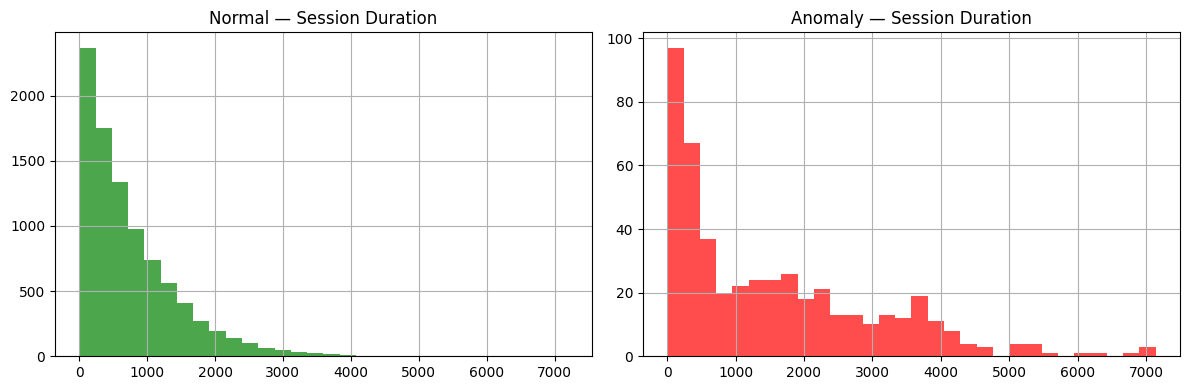

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
normal['session_duration'].hist(bins=30, color='green', alpha=0.7, ax=axes[0])
axes[0].set_title('Normal — Session Duration')
anomalies['session_duration'].hist(bins=30, color='red', alpha=0.7, ax=axes[1])
axes[1].set_title('Anomaly — Session Duration')
plt.tight_layout()
plt.show()